In [13]:
import pickle
import pandas as pd
import numpy as np
from pypcd4 import PointCloud
import cv2
from PIL import Image

In [94]:
# Необходимые столбцы
cuboids_columns = ['uuid', 'label', 'yaw', 'position.x', 'position.y', 'position.z', 'dimensions.x', 'dimensions.y', 'dimensions.z']
pcd_columns = ['x', 'y', 'z', 'i']

# Квадрат для препроцессинга
PCD_AREA_WIDTH = 50
PCD_AREA_HEIGHT = 50

# Размер изображения после препроцессинга
BEV_WIDTH = 640
BEV_HEIGHT = 640

# Ограничения по дальности лидара
WIDTH_MAGIC = 50
HEIGHT_MAGIC = 50

In [96]:
with open('.\\tests\\annotations\\cuboids\\00.pkl.', 'rb') as f:
    cuboids_data = pickle.load(f)

with open('.\\tests\\lidar\\00.pkl.', 'rb') as f:
    lidar_data = pickle.load(f)

with open('.\\tests\\annotations\\semseg\\00.pkl.', 'rb') as f:
    semseg_data = pickle.load(f)

C:\Users\ilyaa\AppData\Local\Temp\ipykernel_32964\1340032899.py:2: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  cuboids_data = pickle.load(f)
C:\Users\ilyaa\AppData\Local\Temp\ipykernel_32964\1340032899.py:5: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  lidar_data = pickle.load(f)
C:\Users\ilyaa\AppData\Local\Temp\ipykernel_32964\1340032899.py:8: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  semseg_data = pickle.load(f)


In [97]:
# Из чего состоят
print(cuboids_data[cuboids_columns].iloc[0])
# print(lidar_data.iloc[0])

uuid            2c4dbdea-845e-4d29-8a94-9c86feb536fe
label                                            Car
yaw                                         2.380306
position.x                                    20.759
position.y                                    31.401
position.z                                     0.591
dimensions.x                                   1.867
dimensions.y                                   4.629
dimensions.z                                   1.673
Name: 0, dtype: object


In [98]:
points_array = lidar_data[pcd_columns].to_numpy()
cuboids_array = cuboids_data[cuboids_columns].to_numpy()
# pcd = PointCloud.from_xyzi_points(points_array)

In [99]:
cuboids_array = cuboids_data[cuboids_columns].to_numpy()

# Определяем края для обучения
x_min = np.min(cuboids_array[:, 3])
x_max = np.max(cuboids_array[:, 3])
x_max_dim = np.max(cuboids_array[:, 6])

y_min = np.min(cuboids_array[:, 4])
y_max = np.max(cuboids_array[:, 4])
y_max_dim = np.max(cuboids_array[:, 7])

x_min_border = max(x_min - x_max_dim, -WIDTH_MAGIC)
x_max_border = min(x_max + x_max_dim, WIDTH_MAGIC)

y_min_border = max(y_min - y_max_dim, -HEIGHT_MAGIC)
y_max_border = min(y_max + y_max_dim, HEIGHT_MAGIC)

print(f"Зона для обучения: [({x_min_border}, {y_min_border}) : ({x_max_border}, {y_max_border})]")

# y (cols)
# |
# |
# 0 --- x  (rows)

row_num = int((x_max_border - x_min_border - 1) // PCD_AREA_WIDTH + 1)
col_num = int((y_max_border - y_min_border - 1) // PCD_AREA_HEIGHT + 1)
print(f"{row_num}x{col_num} зон для обучения")

# Для нормализации z
z_min = np.min(points_array[:, 2])
z_max = np.max(points_array[:, 2])

Зона для обучения: [(-50, -50) : (50, 50)]
2x2 зон для обучения


In [101]:
# Распределение всех точек по необходимым зонам (row_num x col_num)
def get_point_areas(points_array, row_num, col_num, x_min_border, y_min_border):
    point_areas = [[[] for _ in range((col_num))] for _ in range(row_num)]

    for point in points_array:
        
        x_idx = int((point[0] - x_min_border) // PCD_AREA_WIDTH)
        y_idx = int((point[1] - y_min_border) // PCD_AREA_HEIGHT)
        if x_idx >= 0 and y_idx >= 0 and x_idx < row_num and y_idx < col_num:
            point_areas[x_idx][y_idx].append(point)
    
    return point_areas

def get_cuboid_areas(cuboids_array, row_num, col_num, x_min_border, y_min_border):
    cuboid_areas = [[[] for _ in range((col_num))] for _ in range(row_num)]

    for cuboid in cuboids_array:
        x_idx = int((cuboid[3] - x_min_border) // PCD_AREA_WIDTH)
        y_idx = int((cuboid[4] - y_min_border) // PCD_AREA_HEIGHT)
        if x_idx >= 0 and y_idx >= 0 and x_idx < row_num and y_idx < col_num:
            cuboid_areas[x_idx][y_idx].append(cuboid)
    
    return cuboid_areas

point_areas = get_point_areas(points_array, row_num, col_num, x_min_border, y_min_border)
cuboid_areas = get_cuboid_areas(cuboids_array, row_num, col_num, x_min_border, y_min_border)
# print(len(point_areas))
# print(np.max(np.asarray(point_areas[0][0])[:, 0]))


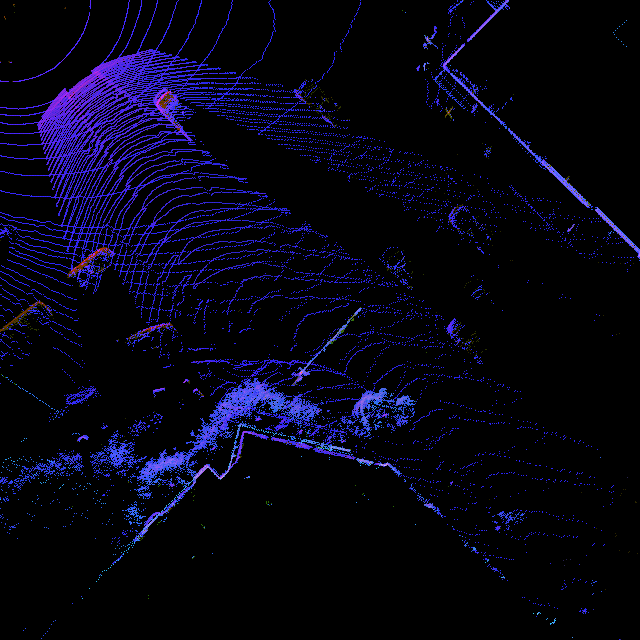

In [104]:
# Create (x, y): (counts, maxZ) dict
def get_CoordToCountValInt_dict(points):
    coord_to_countval = dict()
    for point in points:
        if coord_to_countval.get((point[0], point[1])) == None:
            coord_to_countval[((point[0], point[1]))] = [1, point[2], point[3]]
        else:
            coord_to_countval[((point[0], point[1]))][0] += 1
    return coord_to_countval


def pcd_to_img_map(points_array, x_idx, y_idx, x_min_border, y_min_border, z_min, z_max):
    x_min_area_border = x_min_border + x_idx * PCD_AREA_WIDTH
    y_min_area_border = y_min_border + y_idx * PCD_AREA_HEIGHT

    # Нормализуем x,y [0: 1]
    points_array[:, 0] = (points_array[:, 0] - x_min_area_border) / PCD_AREA_WIDTH
    points_array[:, 1] = (points_array[:, 1] - y_min_area_border) / PCD_AREA_HEIGHT

    # Приводим x,y к [0: BEV_H/BEV_W]
    points_array[:, 0] = np.int32(points_array[:, 0] * BEV_WIDTH)
    points_array[:, 1] = np.int32(points_array[:, 1] * BEV_HEIGHT)

    # Приводим z к [0, 1]
    points_array[:, 2] = (points_array[:, 2] - z_min) / (z_max - z_min)

    # Сортируем (увел х, увел y, умен z)
    ix = np.lexsort((-points_array[:, 2], points_array[:, 1], points_array[:, 0]))
    points_array = points_array[ix]

    height_map = np.zeros((BEV_HEIGHT, BEV_WIDTH))
    density_map = np.zeros((BEV_HEIGHT, BEV_WIDTH))
    intensity_map = np.zeros((BEV_HEIGHT, BEV_WIDTH))

    points_array[:, 0] = np.minimum(np.maximum(points_array[:, 0], 0), BEV_HEIGHT - 1)
    points_array[:, 1] = np.minimum(np.maximum(points_array[:, 1], 0), BEV_WIDTH - 1)

    coord_to_countval = get_CoordToCountValInt_dict(points_array)
    # points_array = points_array[ix]

    for ((x, y), (c, z, i)) in coord_to_countval.items():
        density_map[int(x)][int(y)] = min(1.0, np.log(c + 1) / np.log(64))
        height_map[int(x)][int(y)] = z
        intensity_map[int(x)][int(y)] = i

    img_map = np.zeros([BEV_HEIGHT, BEV_WIDTH, 3])
    img_map[:,:,0] = density_map
    img_map[:,:,1] = height_map
    # img_map[:,:,2] = height_map
    # img_map[:,:,2] = np.full([BEV_HEIGHT, BEV_WIDTH ], 1)
    img_map[:,:,2] = intensity_map
    
    return img_map

temp = np.asarray(point_areas[1][1])
img = pcd_to_img_map(temp, 1, 1, x_min_border, y_min_border, z_min, z_max)

bevImage = img * 255

# cv2.imshow("BEV", img)
# cv2.waitKey(0)
# cv2.destroyAllWindows()
cv2.imwrite("test.png", bevImage.astype(np.uint8))
img = Image.fromarray(bevImage.astype(np.uint8))
img

In [ ]:
for x in range(row_num):
    for y in range(col_num):
        cur_area_point_arr = np.asarray(point_areas[x][y])
        cur_area_cuboid_arr = np.asarray(cuboid_areas[x][y])

        if len(cur_area_cuboid_arr) * len(cur_area_point_arr) == 0:
            continue
        
        img = pcd_to_img_map(cur_area_point_arr, x, y, x_min_border, y_min_border, z_min, z_max)
        bevImage = img * 255
        cv2.imwrite(f"test{x}{y}.png", bevImage.astype(np.uint8))


IndexError: list index out of range